# 05 · Audio Tower Anatomy: 10ms In, 40ms Out

**Hardware**: 🟢 CPU. Downloads the processor config only (~35MB) — **no model weights**. The tower is built from a small config with random weights; the arithmetic is what matters.

## What you will do

1. Derive **40ms per audio token** from the feature extractor's settings and the convolution stack
2. Trace a synthetic waveform through mel extraction and 4× subsampling, printing shapes
3. Reimplement the chunked-attention mask and check it against the library
4. See the 4D mask folded into its 5D blocked form
5. Understand why `attention_context_right = 0` matters

In [1]:
%pip install -q "transformers>=5.14" torch numpy matplotlib

In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from transformers import AutoProcessor, Gemma4AudioConfig
from transformers.masking_utils import create_bidirectional_mask
from transformers.models.gemma4.modeling_gemma4 import (
    Gemma4AudioModel, sliding_window_mask_function,
)

torch.manual_seed(0)
processor = AutoProcessor.from_pretrained("google/gemma-4-E2B-it")
fe = processor.feature_extractor
print(type(fe).__name__)

  from .autonotebook import tqdm as notebook_tqdm


Gemma4AudioFeatureExtractor


## 1. Where 40ms comes from

In [3]:
for k in ["sampling_rate", "feature_size", "frame_length", "hop_length",
          "fft_length", "min_frequency", "max_frequency", "preemphasis_htk_flavor"]:
    print(f"  {k:24s} {getattr(fe, k)}")

ms_per_frame = 1000 * fe.hop_length / fe.sampling_rate
print(f"\nhop_length / sampling_rate = {fe.hop_length}/{fe.sampling_rate} "
      f"= {ms_per_frame:.0f}ms per mel frame")
print(f"two stride-2 convolutions   = 4x temporal downsample")
print(f"=> {ms_per_frame:.0f}ms x 4 = {ms_per_frame * 4:.0f}ms per audio token")
print(f"\nprocessor.audio_ms_per_token = {processor.audio_ms_per_token}  ✓")

  sampling_rate            16000
  feature_size             128
  frame_length             320
  hop_length               160
  fft_length               512
  min_frequency            0.0
  max_frequency            8000.0
  preemphasis_htk_flavor   True

hop_length / sampling_rate = 160/16000 = 10ms per mel frame
two stride-2 convolutions   = 4x temporal downsample
=> 10ms x 4 = 40ms per audio token

processor.audio_ms_per_token = 40  ✓


## 2. A waveform through the front end

waveform        : 54,400 samples = 3.4s
input_features  : (1, 339, 128)  [batch, frames, mel_bins]
frames          : 339  (~340 expected)


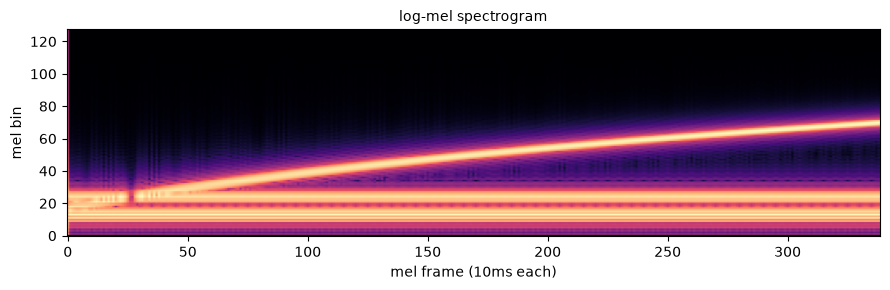

In [4]:
SECONDS = 3.4
sr = fe.sampling_rate
t = np.linspace(0, SECONDS, int(SECONDS * sr), endpoint=False)
# two tones plus a chirp, so the spectrogram has something to look at
wav = (0.3 * np.sin(2 * np.pi * 220 * t)
       + 0.2 * np.sin(2 * np.pi * 440 * t)
       + 0.2 * np.sin(2 * np.pi * (300 + 900 * t / SECONDS) * t)).astype(np.float32)

features = fe([wav], sampling_rate=sr, return_tensors="pt")
input_features = features["input_features"]
input_mask = features.get("input_features_mask",
                          torch.ones(input_features.shape[:2], dtype=torch.bool))

print(f"waveform        : {wav.shape[0]:,} samples = {SECONDS}s")
print(f"input_features  : {tuple(input_features.shape)}  [batch, frames, mel_bins]")
print(f"frames          : {input_features.shape[1]}  (~{SECONDS*1000/ms_per_frame:.0f} expected)")

fig, ax = plt.subplots(figsize=(9, 3))
ax.imshow(input_features[0].T.numpy(), aspect="auto", origin="lower", cmap="magma")
ax.set_xlabel("mel frame (10ms each)"); ax.set_ylabel("mel bin")
ax.set_title("log-mel spectrogram", fontsize=10)
plt.tight_layout(); plt.show()

## 3. Subsampling: 4× in time, 4× in frequency

The mel spectrogram is treated as a **single-channel image** and run through two `Conv2d(3, stride=2, padding=1)` layers. Both axes halve twice.

In [5]:
config = Gemma4AudioConfig(hidden_size=64, num_hidden_layers=2,
                           num_attention_heads=4, output_proj_dims=128)
config._attn_implementation = "eager"
tower = Gemma4AudioModel(config).eval()

print(tower.subsample_conv_projection)

ch0, ch1 = config.subsampling_conv_channels
print(f"\nproj_input_dim = (subsampling_conv_channels[0] // 4) * subsampling_conv_channels[1]")
print(f"               = ({ch0} // 4) * {ch1} = {(ch0 // 4) * ch1}")
print(f"the // 4 is the MEL-BIN reduction ({fe.feature_size} bins -> {fe.feature_size // 4}),")
print(f"and {ch1} is the second conv's output channels. Flatten both -> model width.")

Gemma4AudioSubSampleConvProjection(
  (layer0): Gemma4AudioSubSampleConvProjectionLayer(
    (conv): Conv2d(1, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (norm): LayerNorm((128,), eps=1e-06, elementwise_affine=True)
    (act): ReLU()
  )
  (layer1): Gemma4AudioSubSampleConvProjectionLayer(
    (conv): Conv2d(128, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (norm): LayerNorm((32,), eps=1e-06, elementwise_affine=True)
    (act): ReLU()
  )
  (input_proj_linear): Linear(in_features=1024, out_features=64, bias=False)
)

proj_input_dim = (subsampling_conv_channels[0] // 4) * subsampling_conv_channels[1]
               = (128 // 4) * 32 = 1024
the // 4 is the MEL-BIN reduction (128 bins -> 32),
and 32 is the second conv's output channels. Flatten both -> model width.


In [6]:
hidden, out_mask = tower.subsample_conv_projection(input_features, input_mask)

print(f"input_features : {tuple(input_features.shape)}")
print(f"after SSCP     : {tuple(hidden.shape)}   <- time / 4, and now hidden_size wide")
print(f"mask           : {tuple(out_mask.shape)}, {int(out_mask.sum())} valid")

expected = processor._compute_audio_num_tokens(wav, sr)
print(f"\nprocessor predicted {expected} tokens; the tower produced {hidden.shape[1]}")
print(f"duration_ms / 40 = {SECONDS * 1000 / 40:.0f}")
assert expected == hidden.shape[1], "processor and encoder disagree -- this is the bug the docstring warns about"
print("\nThe processor must predict this exactly, because placeholders go into input_ids")
print("BEFORE the model runs (chapter 02).")

input_features : (1, 339, 128)
after SSCP     : (1, 85, 64)   <- time / 4, and now hidden_size wide
mask           : (1, 85), 85 valid

processor predicted 85 tokens; the tower produced 85
duration_ms / 40 = 85

The processor must predict this exactly, because placeholders go into input_ids
BEFORE the model runs (chapter 02).


In [7]:
with torch.no_grad():
    out = tower(input_features=input_features, attention_mask=input_mask)
print("tower output:", tuple(out.last_hidden_state.shape),
      f"  <- output_proj_dims={config.output_proj_dims}")
print("output_proj is the only projection in the tower WITH a bias:")
print("  ", tower.output_proj)

tower output: (1, 85, 128)   <- output_proj_dims=128
output_proj is the only projection in the tower WITH a bias:
   Linear(in_features=64, out_features=128, bias=True)


On E2B, `output_proj_dims=1536` happens to equal the text model's `hidden_size`, so `embed_audio` is a same-width refinement rather than a resize.

## 4. Chunked attention, by hand

Three config values define the pattern.

In [8]:
chunk = config.attention_chunk_size
left = config.attention_context_left - 1
right = config.attention_context_right
context = chunk + left + right

print(f"attention_chunk_size    = {chunk:3d}   -> {chunk * 40}ms of queries per block")
print(f"attention_context_left  = {config.attention_context_left:3d}  (max_past_horizon = {left})")
print(f"attention_context_right = {right:3d}   <- NO LOOKAHEAD")
print(f"context_size            = {context:3d}   -> {context * 40}ms of keys per block")

attention_chunk_size    =  12   -> 480ms of queries per block
attention_context_left  =  13  (max_past_horizon = 12)
attention_context_right =   0   <- NO LOOKAHEAD
context_size            =  24   -> 960ms of keys per block


In [9]:
T = 40
h = torch.zeros(1, T, config.hidden_size)
valid = torch.ones(1, T, dtype=torch.bool)

lib_4d = create_bidirectional_mask(
    config=config, inputs_embeds=h, attention_mask=valid,
    and_mask_function=sliding_window_mask_function((left, right)),
)
lib_bool = lib_4d[0, 0] if lib_4d.dtype == torch.bool else (lib_4d[0, 0] > -1e30)

# reimplement the predicate directly
mine = torch.tensor([[(0 <= q - k < left) or (0 < k - q < right) for k in range(T)]
                     for q in range(T)])

assert torch.equal(lib_bool, mine)
print("hand-written chunked-attention pattern matches the library ✓\n")
for q in range(14):
    print("  " + "".join("#" if x else "." for x in lib_bool[q].tolist()))

hand-written chunked-attention pattern matches the library ✓

  #.......................................
  ##......................................
  ###.....................................
  ####....................................
  #####...................................
  ######..................................
  #######.................................
  ########................................
  #########...............................
  ##########..............................
  ###########.............................
  ############............................
  .############...........................
  ..############..........................


A band, not a triangle: each frame sees at most `left` frames back and nothing forward. In real terms that is **480ms of lookback and zero lookahead**, which is what makes this encoder structurally capable of running on a live microphone. Whisper, by contrast, attends bidirectionally over a padded 30-second window and cannot start until the utterance is over.

## 5. The 5D blocked form

Attention is computed block-wise, so the mask has to be gathered into matching shape.

4D mask : (1, 1, 40, 40)   [batch, 1, seq, seq]
5D mask : (1, 1, 4, 12, 24)   [batch, 1, num_blocks, chunk_size, context_size]

num_blocks = ceil(40 / 12) = 4


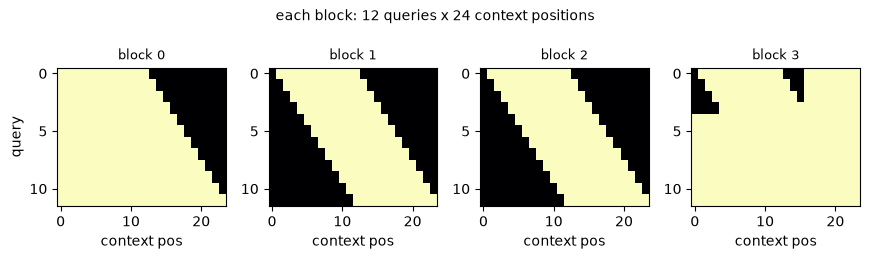

Full attention over a 10-minute recording (15,000 tokens) is 225M pairs per head.
Chunked is num_blocks x 12 x 24 — for 15,000 tokens, about 360K.
Speech is local; the long-range budget is spent in the language decoder instead.


In [10]:
blocked = tower._convert_4d_mask_to_blocked_5d(lib_4d)
print(f"4D mask : {tuple(lib_4d.shape)}   [batch, 1, seq, seq]")
print(f"5D mask : {tuple(blocked.shape)}   [batch, 1, num_blocks, chunk_size, context_size]")
print(f"\nnum_blocks = ceil({T} / {chunk}) = {-(-T // chunk)}")

bb = blocked[0, 0] if blocked.dtype == torch.bool else (blocked[0, 0] > -1e30)
fig, axes = plt.subplots(1, bb.shape[0], figsize=(2.2 * bb.shape[0], 2.6))
for i, ax in enumerate(np.atleast_1d(axes)):
    ax.imshow(bb[i].numpy(), cmap="magma", interpolation="nearest", aspect="auto")
    ax.set_title(f"block {i}", fontsize=9)
    ax.set_xlabel("context pos"); ax.set_ylabel("query" if i == 0 else "")
plt.suptitle("each block: 12 queries x 24 context positions", fontsize=10)
plt.tight_layout(); plt.show()

print("Full attention over a 10-minute recording (15,000 tokens) is 225M pairs per head.")
print(f"Chunked is num_blocks x {chunk} x {context} — for 15,000 tokens, about 360K.")
print("Speech is local; the long-range budget is spent in the language decoder instead.")

## 6. Numerical defensiveness

Between clipped linears, per-layer activation clamping, logit softcapping and float32 attention, the audio tower is the most numerically defensive code in the model. Speech has enormous dynamic range and it shows.

In [11]:
layer = tower.layers[0]
print("layer modules:")
for name, mod in layer.named_children():
    print(f"   {name:16s} {type(mod).__name__}")

attn = layer.self_attn
print(f"\nsoftcap            : {float(attn.softcap)}  -> attn_weights = tanh(w/cap)*cap")
print(f"q_scale            : {attn.q_scale:.6f}  = head_dim^-0.5 / log(2)")
print(f"k_scale            : {attn.k_scale:.6f}  = log(1+e) / log(2)")
print(f"per_dim_scale      : {tuple(attn.per_dim_scale.shape)}  (learned, via softplus)")
print(f"gradient_clipping  : {layer.gradient_clipping:g}  (clamped to dtype max at runtime)")
print(f"use_clipped_linears: {config.use_clipped_linears}")

print("\nDividing both scales by log(2) turns the softmax into base-2 — exp2 is cheaper")
print("than exp, and folding the constant into the projections makes it free.")

layer modules:
   feed_forward1    Gemma4AudioFeedForward
   feed_forward2    Gemma4AudioFeedForward
   self_attn        Gemma4AudioAttention
   lconv1d          Gemma4AudioLightConv1d
   norm_pre_attn    Gemma4RMSNorm
   norm_post_attn   Gemma4RMSNorm
   norm_out         Gemma4RMSNorm

softcap            : 50.0  -> attn_weights = tanh(w/cap)*cap
q_scale            : 0.360674  = head_dim^-0.5 / log(2)
k_scale            : 1.894636  = log(1+e) / log(2)
per_dim_scale      : (16,)  (learned, via softplus)
gradient_clipping  : 1e+10  (clamped to dtype max at runtime)
use_clipped_linears: True

Dividing both scales by log(2) turns the softmax into base-2 — exp2 is cheaper
than exp, and folding the constant into the projections makes it free.


## Exercises

1. Change `hop_length` to 320 and recompute ms-per-token. What else would have to change for the processor and encoder to still agree?
2. Feed a 45-second waveform. What does `_compute_audio_num_tokens` return, and what does the tower produce? Explain the discrepancy.
3. Set `attention_context_right = 4`. Redraw the mask. What has the encoder gained, and what has it lost?
4. Verify the frequency reduction: print `hidden.shape` after `layer0` only, before `layer1`.
5. The subsampling convs are kernel 3 / stride 2 / padding 1 and are **not** in `Gemma4AudioConfig`. Find both places in the codebase that hard-code them.
6. Compare with [chapter 04](../../04-vision-tower/index.md): the vision tower uses 2D RoPE, the audio tower uses Transformer-XL relative position. Argue why each is right for its modality.

## Where next

`02_asr_and_video.ipynb` (forthcoming) runs the real E2B weights, and [`03_whisper_asr_compare.ipynb`](03_whisper_asr_compare.ipynb) is the design-space control.